# UK E-Commerce Analytics - Exploratory Data Analysis

**Dataset:** UK E-Commerce Transactions (Kaggle)
**Source table:** SQL Server -- uk_ecommerce database  
**Pipeline:** CSV -- Python load -- SQL Server -- dbt models  
**Author:** Rutvi Patel  

## Objectives
1. Understand overall sales performance and trends
2. Identify top performing products and countries
3. Analyse customer behaviour and segmentation
4. Validate dbt model outputs

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sqlalchemy
from sqlalchemy import create_engine, text
import urllib
import warnings

warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

# Database connection
DATABASE = 'uk_ecommerce'

connection_string = (
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER=localhost\\SQLEXPRESS;"
    f"DATABASE={DATABASE};"
    f"Trusted_Connection=yes;"
    f"TrustServerCertificate=yes;"
)

encoded = urllib.parse.quote_plus(connection_string)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={encoded}")

# Test connection
with engine.connect() as conn:
    result = conn.execute(text("SELECT @@SERVERNAME"))
    server = result.fetchone()[0]
    print(f"Connected successfully!")
    print(f"Server:   {server}")
    print(f"Database: {DATABASE}")

Connected successfully!
Server:   Rutvi\SQLEXPRESS
Database: uk_ecommerce


## 1. LOad Data From SQL Server
Loading all dbt mart tables directly into pandas DataFrames

In [46]:
df_sales = pd.read_sql("SELECT * FROM DBO.fct_sales", engine)
df_rfm = pd.read_sql("SELECT * FROM dbo.fct_rfm_segments", engine)
df_cohort = pd.read_sql("SELECT * FROM dbo.fct_cohort", engine)
df_country = pd.read_sql("SELECT * FROM dbo.fct_country_sales", engine)
df_raw = pd.read_sql("SELECT * FROM dbo.stg_transactions", engine)

print("Table Loaded sucessfully")
print(f" Sales rows: {len(df_sales):,}")
print(f"RFM rows:      {len(df_rfm):,}")
print(f"Cohort rows:   {len(df_cohort):,}")
print(f"Country rows:  {len(df_country):,}")
print(f"Raw rows:      {len(df_raw):,}")

Table Loaded sucessfully
 Sales rows: 305
RFM rows:      4,334
Cohort rows:   91
Country rows:  38
Raw rows:      527,935


## 2. Dataset Overview

In [47]:
print("=" * 50)
print("Sales Table")
print("=" * 50)
print(df_sales.dtypes)
print(f"\nData range : {df_sales['sales_date'].min()} to {df_sales['sales_date'].max()}")


print("\n" + "=" * 50)
print("KEY BUSINESS METRICS")
print("=" * 50)
print(f"Total Revenue:       £{df_sales['total_revenue'].sum():,.2f}")
print(f"Total Orders:        {df_sales['total_orders'].sum():,}")
print(f"Total Customers:     {len(df_rfm):,}")
print(f"Total Countries:     {len(df_country):,}")
print(f"Avg Order Value:     £{df_sales['avg_order_value'].mean():,.2f}")
print(f"Date Range:          {df_sales['sales_date'].min()} → {df_sales['sales_date'].max()}")

Sales Table
sales_date              object
sales_year               int64
sales_month              int64
sales_month_name           str
sales_quarter            int64
sales_day_name             str
total_orders             int64
unique_customers         int64
total_line_items         int64
total_units_sold         int64
total_revenue          float64
avg_line_item_value    float64
avg_order_value        float64
dtype: object

Data range : 2010-12-01 to 2011-12-09

KEY BUSINESS METRICS
Total Revenue:       £10,304,056.07
Total Orders:        19,781
Total Customers:     4,334
Total Countries:     38
Avg Order Value:     £517.28
Date Range:          2010-12-01 → 2011-12-09


In [48]:
## 3. Sales Trend Analysis
Monthly revneue trend to identify seasonality and growth patterns.

SyntaxError: invalid syntax (2747874710.py, line 2)

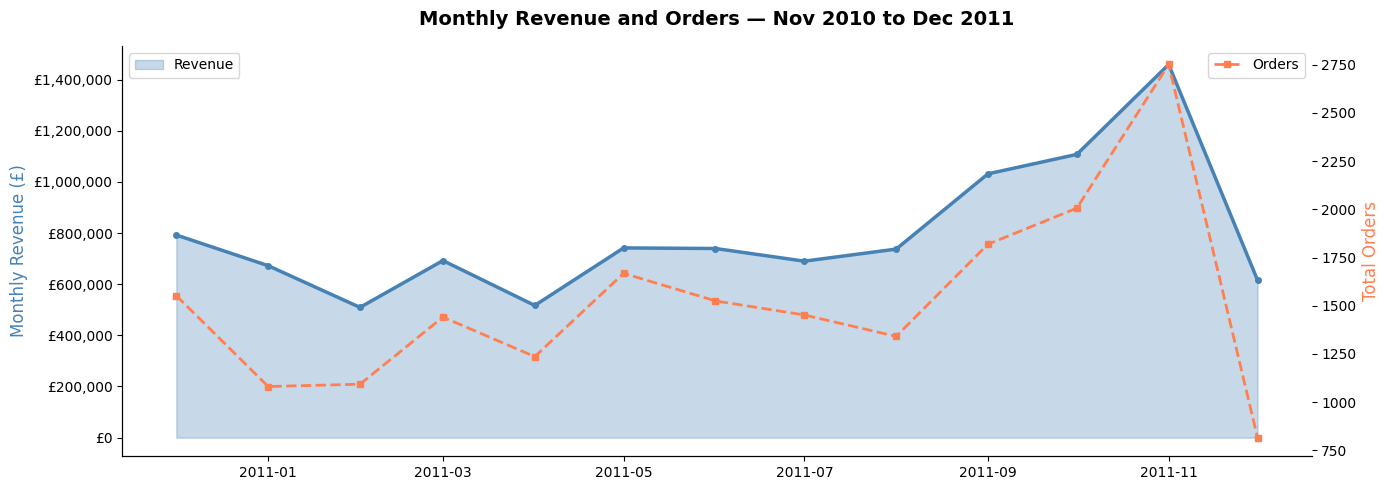


Peak revenue month: November 2011
Peak revenue:       £1,458,895.53
Lowest revenue month: February 2011


In [ ]:

monthly = df_sales.groupby(['sales_year', 'sales_month']).agg(
    total_revenue=('total_revenue', 'sum'),
    total_orders=('total_orders', 'sum')
).reset_index()

monthly['period'] = pd.to_datetime(
    monthly['sales_year'].astype(str) + '-' +
    monthly['sales_month'].astype(str).str.zfill(2) + '-01'
)
monthly = monthly.sort_values('period')

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.fill_between(monthly['period'], monthly['total_revenue'],
                  alpha=0.3, color='steelblue')
ax1.plot(monthly['period'], monthly['total_revenue'],
         color='steelblue', linewidth=2.5, marker='o', markersize=4)
ax1.set_ylabel('Monthly Revenue (£)', color='steelblue', fontsize=12)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, p: f'£{x:,.0f}'
))

ax2 = ax1.twinx()
ax2.plot(monthly['period'], monthly['total_orders'],
         color='coral', linewidth=2, linestyle='--',
         marker='s', markersize=4, label='Orders')
ax2.set_ylabel('Total Orders', color='coral', fontsize=12)

plt.title('Monthly Revenue and Orders — Nov 2010 to Dec 2011',
          fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(['Revenue'], loc='upper left')
ax2.legend(['Orders'], loc='upper right')

plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPeak revenue month: {monthly.loc[monthly['total_revenue'].idxmax(), 'period'].strftime('%B %Y')}")
print(f"Peak revenue:       £{monthly['total_revenue'].max():,.2f}")
print(f"Lowest revenue month: {monthly.loc[monthly['total_revenue'].idxmin(), 'period'].strftime('%B %Y')}")

##4. Revenue by Day of Week
Which days generate the mose revenue?

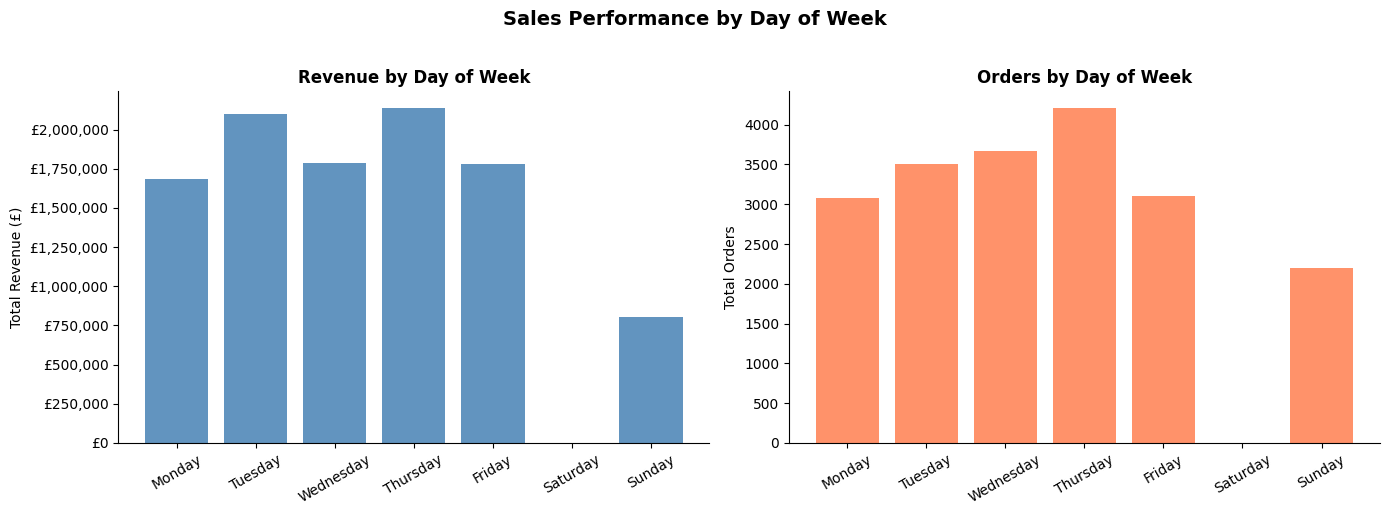

Best day:  Thursday — £2,137,585.27
Worst day: Sunday — £805,848.33


In [ ]:

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

dow = df_sales.groupby('sales_day_name').agg(
    total_revenue=('total_revenue', 'sum'),
    total_orders=('total_orders', 'sum')
).reindex(day_order).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(dow['sales_day_name'], dow['total_revenue'],
            color='steelblue', alpha=0.85)
axes[0].set_title('Revenue by Day of Week', fontweight='bold')
axes[0].set_ylabel('Total Revenue (£)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, p: f'£{x:,.0f}'
))
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(dow['sales_day_name'], dow['total_orders'],
            color='coral', alpha=0.85)
axes[1].set_title('Orders by Day of Week', fontweight='bold')
axes[1].set_ylabel('Total Orders')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Sales Performance by Day of Week',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

best_day = dow.loc[dow['total_revenue'].idxmax(), 'sales_day_name']
worst_day = dow.loc[dow['total_revenue'].idxmin(), 'sales_day_name']
print(f"Best day:  {best_day} — £{dow['total_revenue'].max():,.2f}")
print(f"Worst day: {worst_day} — £{dow['total_revenue'].min():,.2f}")

## 5. Country Analysis
Which countries generate the most revenue? UK dominates — let's quantify.

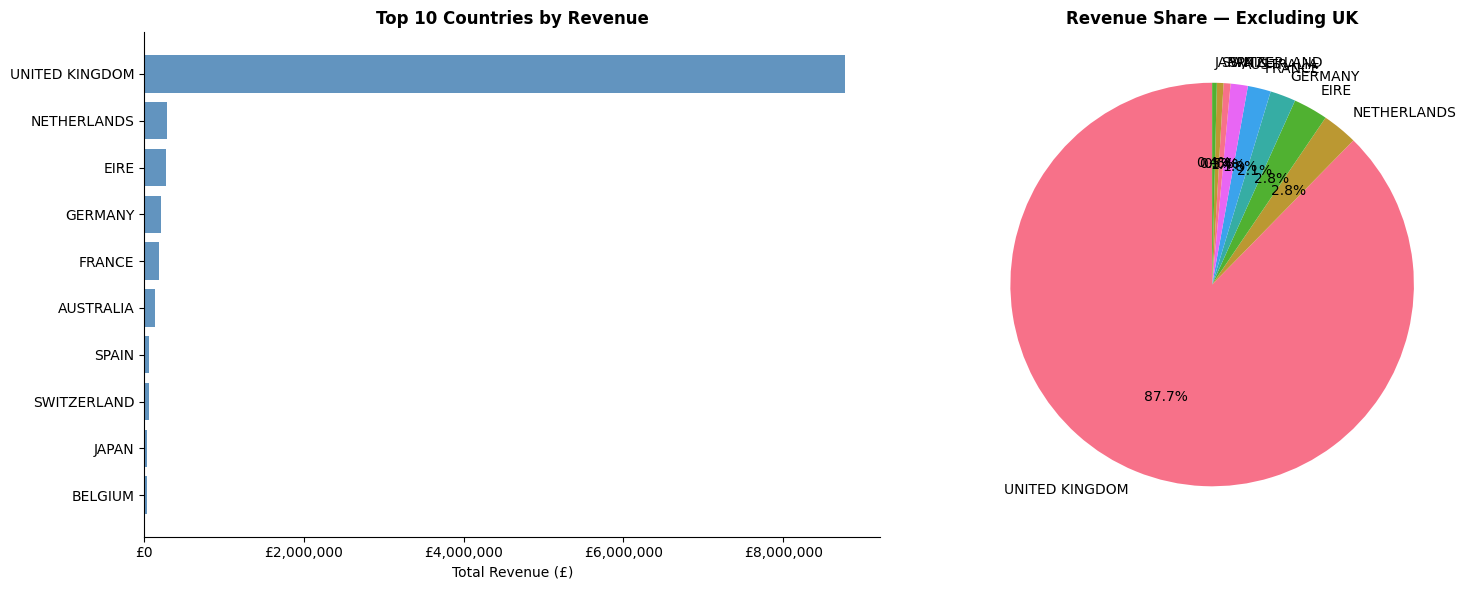

IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
top_countries = df_country.nlargest(10, 'total_revenue')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Revenue by country
bars = axes[0].barh(top_countries['country'],
                     top_countries['total_revenue'],
                     color='steelblue', alpha=0.85)
axes[0].set_title('Top 10 Countries by Revenue', fontweight='bold')
axes[0].set_xlabel('Total Revenue (£)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, p: f'£{x:,.0f}'
))
axes[0].invert_yaxis()

# Revenue share excluding UK
non_uk = df_country[df_country['country'] != 'United Kingdom'].nlargest(9, 'total_revenue')
axes[1].pie(non_uk['total_revenue'],
            labels=non_uk['country'],
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Revenue Share — Excluding UK', fontweight='bold')

plt.tight_layout()
plt.show()

uk_revenue = df_country[df_country['country'] == 'United Kingdom']['total_revenue'].values[0]
total_revenue = df_country['total_revenue'].sum()
print(f"UK Revenue:       £{uk_revenue:,.2f}")
print(f"UK Revenue Share: {uk_revenue/total_revenue*100:.1f}%")
print(f"Number of Countries: {len(df_country)}")

## 6. RFM Customer Segmentation
How are customers distributed across segments?

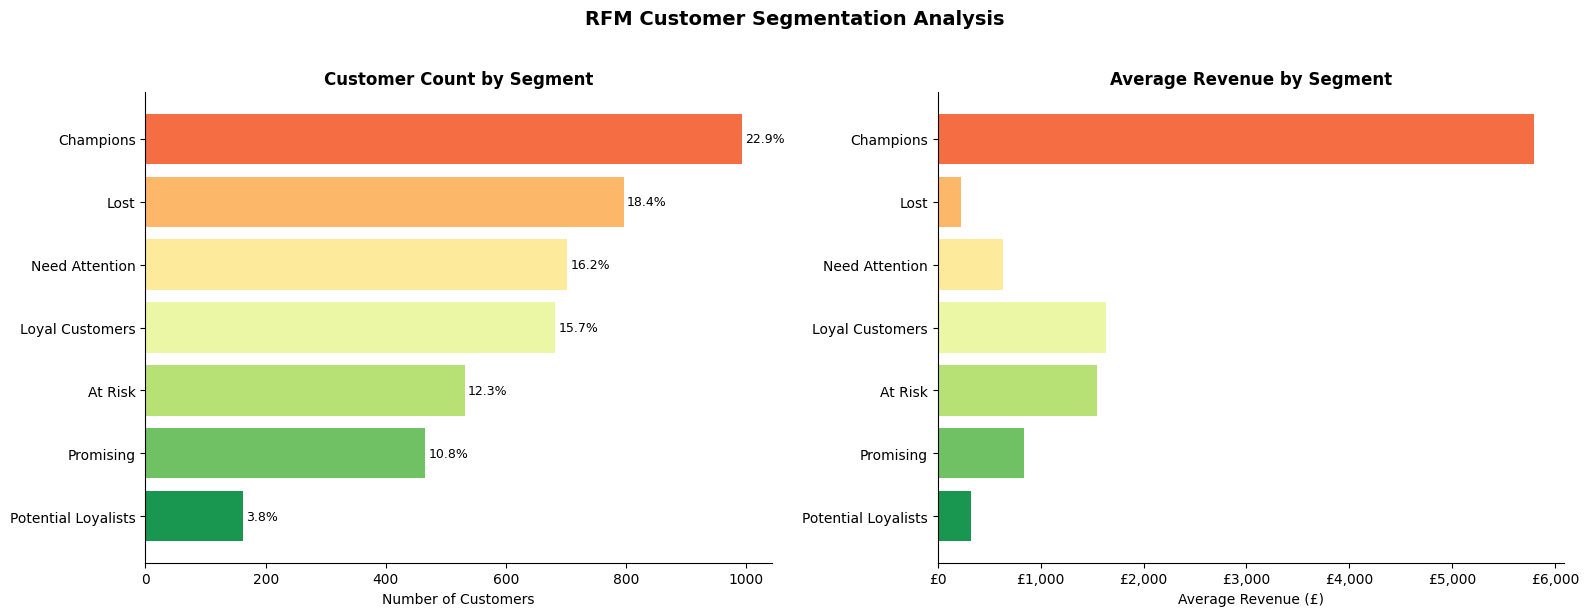


Segment Summary:
            segment  customer_count  avg_revenue  avg_frequency  avg_recency
          Champions             993  5800.966727      10.698892    13.156093
               Lost             796   223.145465       1.000000   229.057789
     Need Attention             702   637.984772       1.451567   129.051282
    Loyal Customers             682  1632.465088       4.343109    40.524927
            At Risk             532  1551.692782       3.550752   143.637218
          Promising             466   836.971845       1.491416    16.444206
Potential Loyalists             163   325.355583       2.576687    38.895706


In [ ]:

segment_summary = df_rfm.groupby('segment').agg(
    customer_count=('customer_id', 'count'),
    avg_revenue=('monetary', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_recency=('recency_days', 'mean')
).reset_index().sort_values('customer_count', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.cm.RdYlGn(
    np.linspace(0.2, 0.9, len(segment_summary))
)

axes[0].barh(segment_summary['segment'],
              segment_summary['customer_count'],
              color=colors)
axes[0].set_title('Customer Count by Segment', fontweight='bold')
axes[0].set_xlabel('Number of Customers')
axes[0].invert_yaxis()

for i, (count, pct) in enumerate(zip(
    segment_summary['customer_count'],
    segment_summary['customer_count'] / len(df_rfm) * 100
)):
    axes[0].text(count + 5, i, f'{pct:.1f}%', va='center', fontsize=9)

axes[1].barh(segment_summary['segment'],
              segment_summary['avg_revenue'],
              color=colors)
axes[1].set_title('Average Revenue by Segment', fontweight='bold')
axes[1].set_xlabel('Average Revenue (£)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, p: f'£{x:,.0f}'
))
axes[1].invert_yaxis()

plt.suptitle('RFM Customer Segmentation Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nSegment Summary:")
print(segment_summary[['segment','customer_count','avg_revenue',
                         'avg_frequency','avg_recency']].to_string(index=False))

## 7. Cohort Retention Analysis
What percentage of customers return each month after their first purchase?

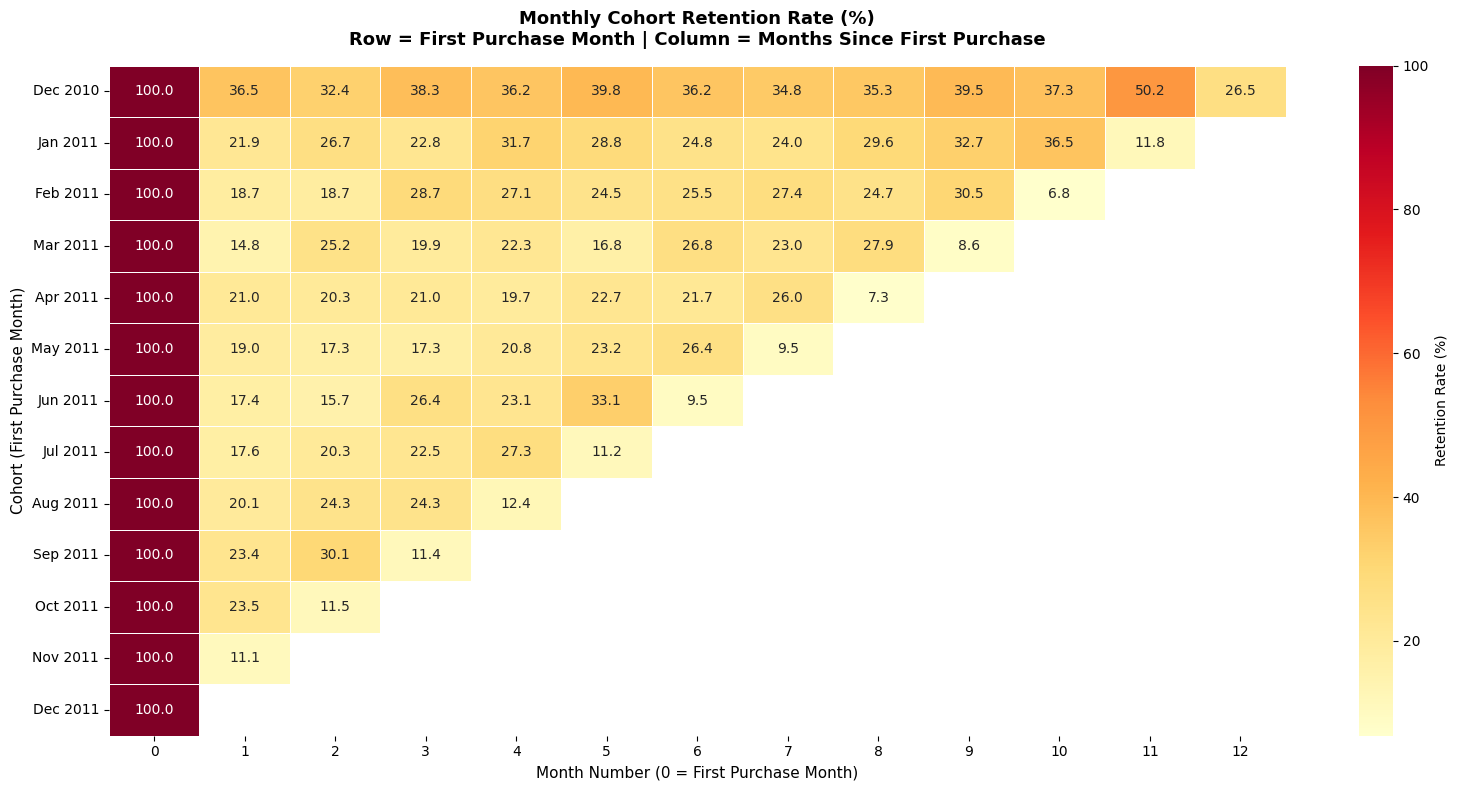

Average Month 1 Retention: 20.4%
Average Month 3 Retention: 23.3%


In [ ]:

df_cohort['cohort_month'] = pd.to_datetime(df_cohort['cohort_month'])
df_cohort['cohort_label'] = df_cohort['cohort_month'].dt.strftime('%b %Y')

cohort_pivot = df_cohort.pivot_table(
    index='cohort_label',
    columns='month_number',
    values='retention_rate'
)

cohort_order = df_cohort.sort_values('cohort_month')['cohort_label'].unique()
cohort_pivot = cohort_pivot.reindex(cohort_order)

fig, ax = plt.subplots(figsize=(16, 8))

sns.heatmap(
    cohort_pivot,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': 'Retention Rate (%)'}
)

ax.set_title('Monthly Cohort Retention Rate (%)\nRow = First Purchase Month | Column = Months Since First Purchase',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Month Number (0 = First Purchase Month)', fontsize=11)
ax.set_ylabel('Cohort (First Purchase Month)', fontsize=11)

plt.tight_layout()
plt.savefig('cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

avg_m1_retention = cohort_pivot[1].mean()
avg_m3_retention = cohort_pivot[3].mean()
print(f"Average Month 1 Retention: {avg_m1_retention:.1f}%")
print(f"Average Month 3 Retention: {avg_m3_retention:.1f}%")

## 8. Top Products Analysis

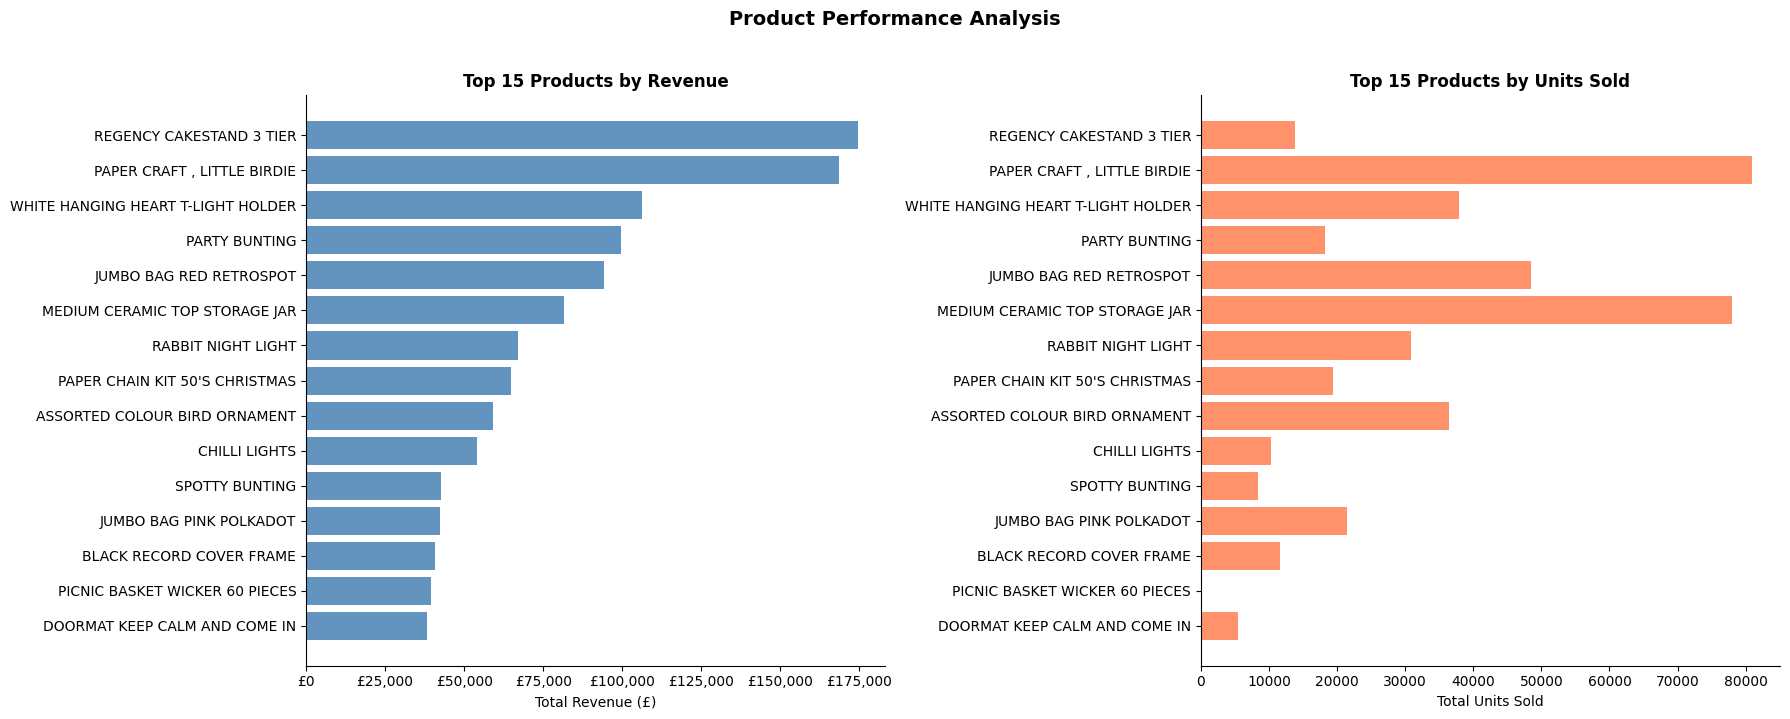

In [ ]:


top_products = df_raw.groupby('description').agg(
    total_revenue=('total_price', 'sum'),
    total_quantity=('quantity', 'sum'),
    order_count=('invoice_no', 'nunique')
).reset_index().nlargest(15, 'total_revenue')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(top_products['description'],
              top_products['total_revenue'],
              color='steelblue', alpha=0.85)
axes[0].set_title('Top 15 Products by Revenue', fontweight='bold')
axes[0].set_xlabel('Total Revenue (£)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, p: f'£{x:,.0f}'
))
axes[0].invert_yaxis()

axes[1].barh(top_products['description'],
              top_products['total_quantity'],
              color='coral', alpha=0.85)
axes[1].set_title('Top 15 Products by Units Sold', fontweight='bold')
axes[1].set_xlabel('Total Units Sold')
axes[1].invert_yaxis()

plt.suptitle('Product Performance Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Key Business Insights Summary

In [ ]:

print("=" * 60)
print("KEY BUSINESS INSIGHTS")
print("=" * 60)

print(f"""
REVENUE
  Total Revenue:          £{df_sales['total_revenue'].sum():>12,.2f}
  Total Orders:           {df_sales['total_orders'].sum():>12,}
  Avg Order Value:        £{df_sales['avg_order_value'].mean():>12,.2f}
  Peak Month:             {monthly.loc[monthly['total_revenue'].idxmax(), 'period'].strftime('%B %Y'):>12}

CUSTOMERS
  Total Customers:        {len(df_rfm):>12,}
  Champions:              {len(df_rfm[df_rfm['segment']=='Champions']):>12,}
  At Risk:                {len(df_rfm[df_rfm['segment']=='At Risk']):>12,}
  Lost:                   {len(df_rfm[df_rfm['segment']=='Lost']):>12,}

GEOGRAPHY
  Total Countries:        {len(df_country):>12,}
  UK Revenue Share:       {uk_revenue/total_revenue*100:>11.1f}%

RETENTION
  Avg Month 1 Retention:  {avg_m1_retention:>11.1f}%
  Avg Month 3 Retention:  {avg_m3_retention:>11.1f}%
""")

KEY BUSINESS INSIGHTS

REVENUE
  Total Revenue:          £10,304,056.07
  Total Orders:                 19,781
  Avg Order Value:        £      517.28
  Peak Month:             November 2011

CUSTOMERS
  Total Customers:               4,334
  Champions:                       993
  At Risk:                         532
  Lost:                            796

GEOGRAPHY
  Total Countries:                  38
  UK Revenue Share:              85.2%

RETENTION
  Avg Month 1 Retention:         20.4%
  Avg Month 3 Retention:         23.3%

